In [ ]:
# ============================================================
# INSTALAR DEPENDENCIAS
# ============================================================

!pip install -q gdown pandas scikit-learn

# ============================================================
# DESCARGAR DATASET DESDE GOOGLE DRIVE
# ============================================================

import gdown

FILE_ID = "1pG1qYiYy2p_dVOTuP2XjW2P430ykq6l-"

ZIP_PATH = "/content/FIFA_2022_ONLY_FACES.zip"

gdown.download(
    id=FILE_ID,
    output=ZIP_PATH,
    quiet=False
)

# ============================================================
# DESCOMPRIMIR
# ============================================================

import zipfile
import os

DATASET_DIR = "/content/FIFA_2022_ONLY_FACES"

os.makedirs(DATASET_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATASET_DIR)

print("Dataset extraído")

# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

# ============================================================
# LEER DATASET
# ============================================================

dataset_root = Path(DATASET_DIR)

VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

rows = []
#==================================================================
# Arregla encoding nombres de los jugadores
#==================================================================
def fix_name(text):
    try:
        return text.encode('latin1').decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):

        replacements = {
            "Ã°Ð½": "í",
            "Ã°Ð±": "á",
            "Ã°Ð©": "é",
            "Ã°Ð³": "ó",
            "Ã°Ðº": "ú",
            "Ã°Ð¼": "ñ",
            "├н": "í",
            "├б": "á",
            "├│": "ó",
            "├▒": "ñ",
            "├Б": "Á",
            "├â": "É",
            "├ì": "Ó",
            "├║": "Ú"
        }

        for bad, good in replacements.items():
            text = text.replace(bad, good)
        return text
#==================================================================
# FILTRA JUGADORES DE LA SELECCION ARGENTINA
#==================================================================

for img_file in dataset_root.rglob("*"):

    if img_file.suffix.lower() not in VALID_EXTENSIONS:
        continue

    path_str = str(img_file)

    # Solo jugadores argentinos
    if "Argentina Players" not in path_str:
        continue

    player_folder = img_file.parent.name

    # Images_Rodrigo De Paul
    player_name = player_folder

    if player_name.startswith("Images_"):
        player_name = player_name[len("Images_"):]

    player_name = fix_name(player_name)

    relative_path = img_file.relative_to(dataset_root)

    rows.append({
        "image_path": str(relative_path),
        "country": "Argentina",
        "label": player_name
    })

df = pd.DataFrame(rows)

print("Imágenes:", len(df))
print("Jugadores:", df["label"].nunique())

print("\nJugadores encontrados:")

for jugador in sorted(df["label"].unique()):
    print(jugador)

# ============================================================
# PARTICIONA TRAIN/VAL/TEST SPLIT 60 / 20 / 20
# ============================================================

train_parts = []
val_parts = []
test_parts = []

for player in df["label"].unique():

    player_df = df[
        df["label"] == player
    ]

    if len(player_df) < 5:
        continue

    train_df, temp_df = train_test_split(
        player_df,
        test_size=0.40,
        random_state=42,
        shuffle=True
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    train_parts.append(train_df)
    val_parts.append(val_df)
    test_parts.append(test_df)

train_df = pd.concat(train_parts).sample(
    frac=1,
    random_state=42
)

val_df = pd.concat(val_parts).sample(
    frac=1,
    random_state=42
)

test_df = pd.concat(test_parts).sample(
    frac=1,
    random_state=42
)

# ============================================================
# ESTADISTICAS
# ============================================================

total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print()
print("TRAIN:", len(train_df))
print("VAL:", len(val_df))
print("TEST:", len(test_df))

print()
print(
    "TRAIN %",
    round(len(train_df)/total*100,2)
)

print(
    "VAL %",
    round(len(val_df)/total*100,2)
)

print(
    "TEST %",
    round(len(test_df)/total*100,2)
)

# ============================================================
# GUARDAR CSV
# ============================================================

train_csv = "/content/train.csv"
val_csv = "/content/val.csv"
test_csv = "/content/test.csv"

train_df.to_csv(
    train_csv,
    index=False,
    encoding="utf-8-sig"
)

val_df.to_csv(
    val_csv,
    index=False,
    encoding="utf-8-sig"
)

test_df.to_csv(
    test_csv,
    index=False,
    encoding="utf-8-sig"
)

print()
print("CSV generados:")
print(train_csv)
print(val_csv)
print(test_csv)

Downloading...
From (original): https://drive.google.com/uc?id=1pG1qYiYy2p_dVOTuP2XjW2P430ykq6l-
From (redirected): https://drive.google.com/uc?id=1pG1qYiYy2p_dVOTuP2XjW2P430ykq6l-&confirm=t&uuid=e23833da-f426-4b2e-88a8-22ed4b863989
To: /content/FIFA_2022_ONLY_FACES.zip
100%|██████████| 538M/538M [00:08<00:00, 62.2MB/s]


Dataset extraído
Imágenes: 1229
Jugadores: 26

Jugadores encontrados:
Alexis Mac Allister
Cristian Romero
Emiliano Martínez
Enzo Fernández
Exequiel Palacios
Franco Armani
Germán Pezzella
Gerónimo Rulli
Gonzalo Montiel
Guido Rodríguez
Juan Foyth
Julián Álvarez
Lautaro Martínez
Leandro Paredes
Lionel Messi (captain)
Lisandro Martínez
Marcos Acuña
Nahuel Molina
Nicolás Otamendi
Nicolás Tagliafico
Papu Gómez
Paulo Dybala
Rodrigo De Paul
Thiago Almada
Ángel Correa
Ángel Di María

TRAIN: 726
VAL: 248
TEST: 255

TRAIN % 59.07
VAL % 20.18
TEST % 20.75

CSV generados:
/content/train.csv
/content/val.csv
/content/test.csv


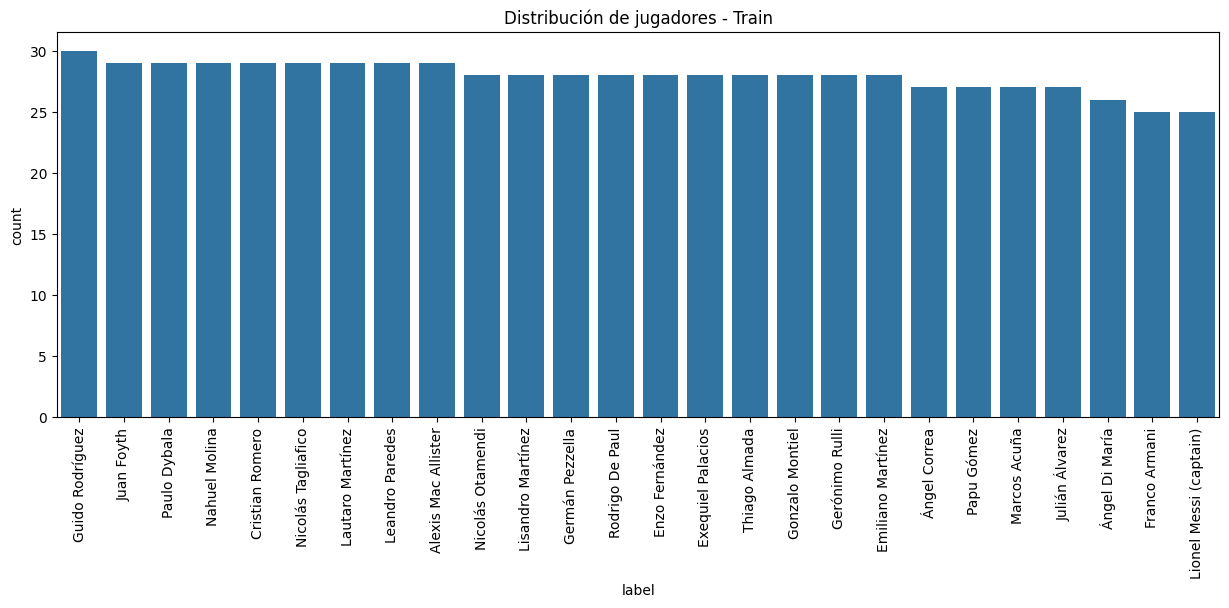

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

sns.countplot(
    data=train_df,
    x="label",
    order=train_df["label"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Distribución de jugadores - Train")
plt.show()

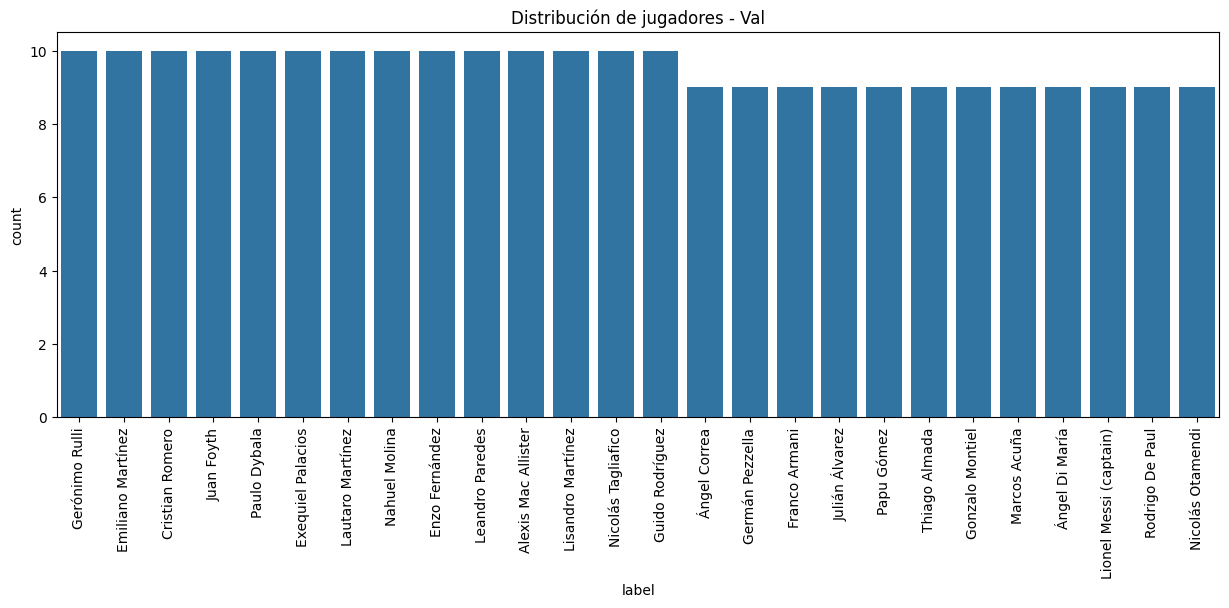

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

sns.countplot(
    data=val_df,
    x="label",
    order=val_df["label"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Distribución de jugadores - Val")
plt.show()

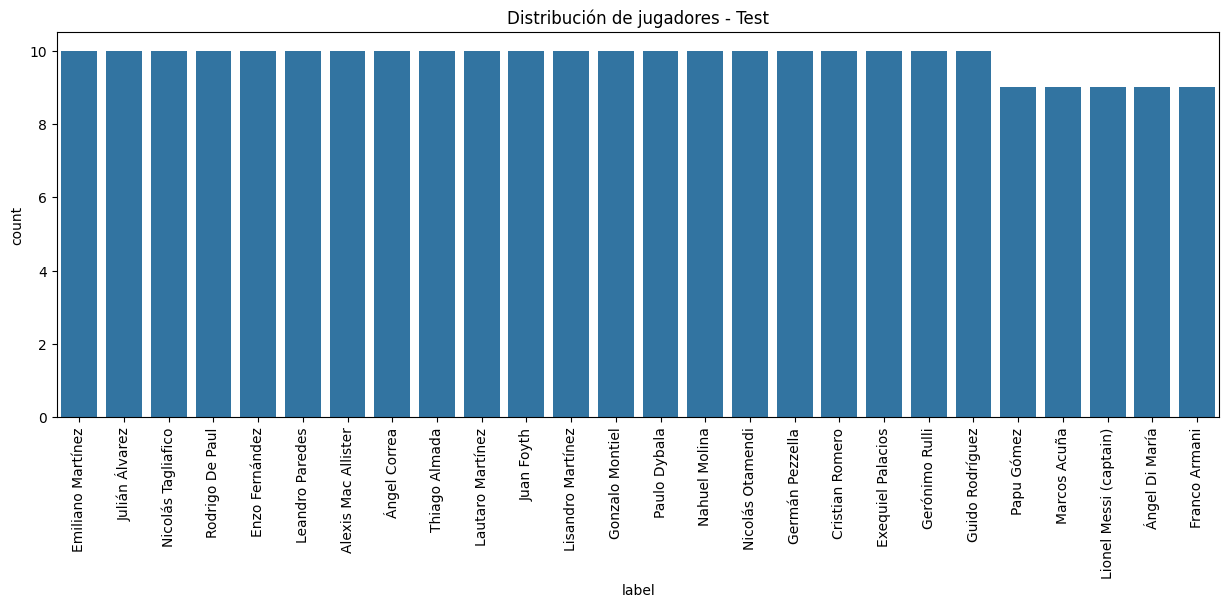

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

sns.countplot(
    data=test_df,
    x="label",
    order=test_df["label"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Distribución de jugadores - Test")
plt.show()

In [ ]:
# Crear Label Encoding

all_labels = sorted(df["label"].unique())

label_to_idx = {
    label: idx
    for idx, label in enumerate(all_labels)
}

idx_to_label = {
    idx: label
    for label, idx in label_to_idx.items()
}

In [ ]:
train_df["label_idx"] = train_df["label"].map(label_to_idx)

val_df["label_idx"] = val_df["label"].map(label_to_idx)

test_df["label_idx"] = test_df["label"].map(label_to_idx)

In [ ]:
train_df.head()


,image_path,country,label,label_idx
518,FIFA_2022_ONLY_FACES/Images/Images/Group C/Arg...,Argentina,Juan Foyth,10
858,FIFA_2022_ONLY_FACES/Images/Images/Group C/Arg...,Argentina,Leandro Paredes,13
952,FIFA_2022_ONLY_FACES/Images/Images/Group C/Arg...,Argentina,Papu Gómez,20
89,FIFA_2022_ONLY_FACES/Images/Images/Group C/Arg...,Argentina,Paulo Dybala,21
966,FIFA_2022_ONLY_FACES/Images/Images/Group C/Arg...,Argentina,Papu Gómez,20


In [ ]:
# transforms y augmentation Train

from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
# transforms Validation/Test

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


In [ ]:
# Instanciar ejemplos
from PIL import Image
import numpy as np

sample_path = (
    dataset_root /
    train_df.iloc[0]["image_path"]
)

img = Image.open(sample_path).convert("RGB")

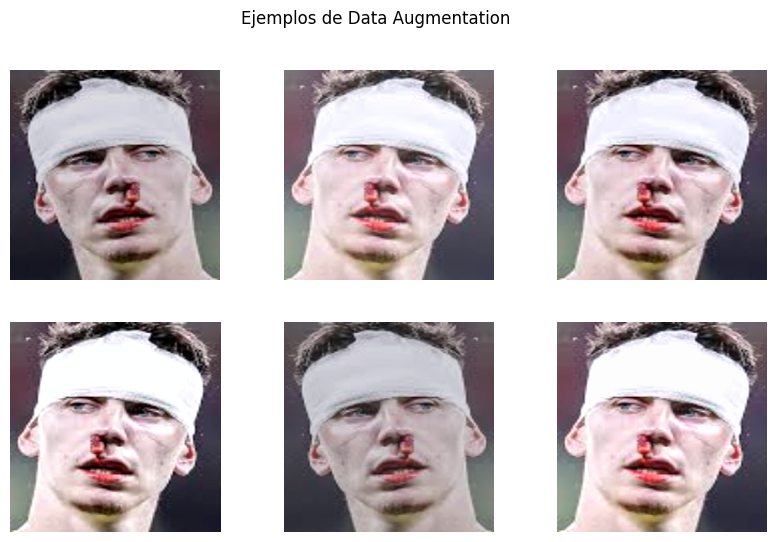

In [ ]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(10,6)
)

for ax in axes.flatten():

    transformed = train_transform(img)

    transformed = transformed.permute(
        1,2,0
    ).numpy()

    mean = np.array([
        0.485,
        0.456,
        0.406
    ])

    std = np.array([
        0.229,
        0.224,
        0.225
    ])

    transformed = std * transformed + mean

    transformed = np.clip(
        transformed,
        0,
        1
    )

    ax.imshow(transformed)
    ax.axis("off")

plt.suptitle(
    "Ejemplos de Data Augmentation"
)

plt.show()

In [ ]:
from torch.utils.data import Dataset

In [ ]:
class FootballDataset(Dataset):

    def __init__(
        self,
        dataframe,
        root_dir,
        transform=None
    ):

        self.dataframe = dataframe
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = (
            self.root_dir /
            row["image_path"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        label = row["label_idx"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_dataset = FootballDataset(
    dataframe=train_df,
    root_dir=DATASET_DIR,
    transform=train_transform
)

val_dataset = FootballDataset(
    dataframe=val_df,
    root_dir=DATASET_DIR,
    transform=val_transform
)

test_dataset = FootballDataset(
    dataframe=test_df,
    root_dir=DATASET_DIR,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

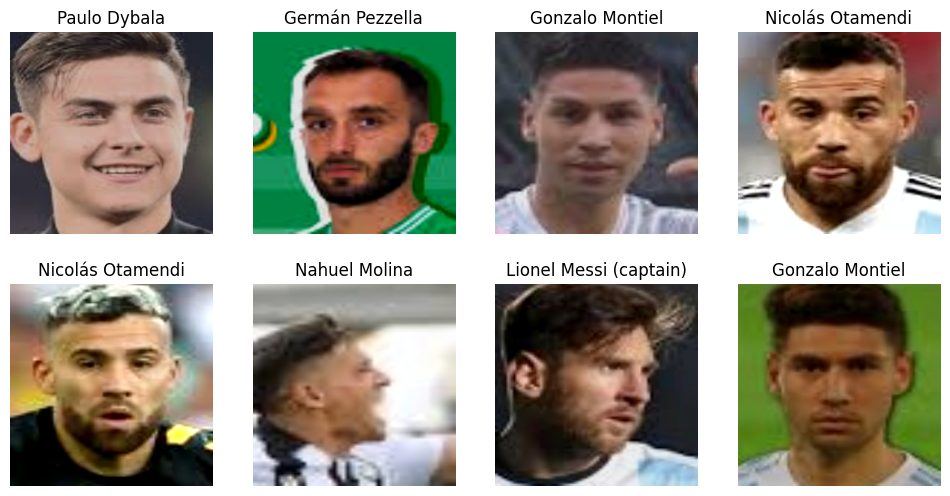

In [ ]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(12,6)
)

# Get a batch of images and labels
images, labels = next(iter(train_loader))

for i, ax in enumerate(
    axes.flatten()
):

    img = images[i]

    img = img.permute(
        1,2,0
    ).numpy()

    mean = np.array([
        0.485,
        0.456,
        0.406
    ])

    std = np.array([
        0.229,
        0.224,
        0.225
    ])

    img = std * img + mean

    img = np.clip(
        img,
        0,
        1
    )

    ax.imshow(img)

    ax.set_title(
        idx_to_label[
            int(labels[i])
        ]
    )

    ax.axis("off")

plt.show()

# Generación automática de Trillizas

Para entrenar la red mediante Triplet Loss se implementa un Dataset especializado.

Cada muestra estará formada por:

- Anchor: imagen de un jugador.
- Positive: otra imagen del mismo jugador.
- Negative: imagen de un jugador diferente.

El objetivo es aprender embeddings que minimicen la distancia entre Anchor y Positive y maximicen la distancia respecto al Negative.

In [ ]:
from collections import defaultdict
import random

class TripletFootballDataset(Dataset):

    def __init__(
        self,
        dataframe,
        root_dir,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.root_dir = Path(root_dir)

        self.transform = transform

        self.class_to_indices = defaultdict(list)

        for idx, row in self.dataframe.iterrows():

            self.class_to_indices[
                row["label_idx"]
            ].append(idx)

        self.labels = list(
            self.class_to_indices.keys()
        )

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        anchor_row = self.dataframe.iloc[idx]

        anchor_label = anchor_row["label_idx"]

        positive_idx = idx

        while positive_idx == idx:

            positive_idx = random.choice(
                self.class_to_indices[
                    anchor_label
                ]
            )

        negative_label = random.choice(
            [
                lbl
                for lbl in self.labels
                if lbl != anchor_label
            ]
        )

        negative_idx = random.choice(
            self.class_to_indices[
                negative_label
            ]
        )

        anchor_img = Image.open(
            self.root_dir /
            anchor_row["image_path"]
        ).convert("RGB")

        positive_img = Image.open(
            self.root_dir /
            self.dataframe.iloc[
                positive_idx
            ]["image_path"]
        ).convert("RGB")

        negative_img = Image.open(
            self.root_dir /
            self.dataframe.iloc[
                negative_idx
            ]["image_path"]
        ).convert("RGB")

        if self.transform:

            anchor_img = self.transform(anchor_img)

            positive_img = self.transform(
                positive_img
            )

            negative_img = self.transform(
                negative_img
            )

        return (
            anchor_img,
            positive_img,
            negative_img,
            anchor_label
        )

In [ ]:
triplet_train_dataset = TripletFootballDataset(
    dataframe=train_df,
    root_dir=DATASET_DIR,
    transform=train_transform
)

In [ ]:
triplet_train_loader = DataLoader(
    triplet_train_dataset,
    batch_size=32,
    shuffle=True
)

In [ ]:
anchor, positive, negative, labels = next(iter(triplet_train_loader))

print(anchor.shape)
print(positive.shape)
print(negative.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 3, 224, 224])
torch.Size([32, 3, 224, 224])


Clase: Juan Foyth


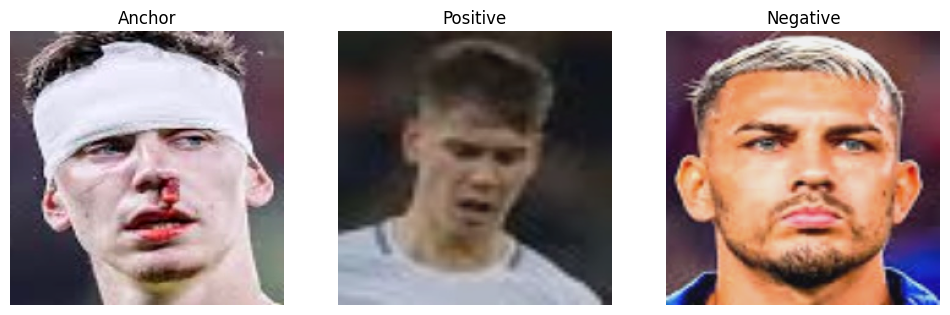

In [ ]:
anchor, positive, negative, label = triplet_train_dataset[0]

print("Clase:", idx_to_label[label])

fig, ax = plt.subplots(1, 3, figsize=(12,4))

# Anchor
img = anchor.permute(1,2,0).numpy()
img = std * img + mean
img = np.clip(img, 0, 1)

ax[0].imshow(img)
ax[0].set_title("Anchor")
ax[0].axis("off")

# Positive
img = positive.permute(1,2,0).numpy()
img = std * img + mean
img = np.clip(img, 0, 1)

ax[1].imshow(img)
ax[1].set_title("Positive")
ax[1].axis("off")

# Negative
img = negative.permute(1,2,0).numpy()
img = std * img + mean
img = np.clip(img, 0, 1)

ax[2].imshow(img)
ax[2].set_title("Negative")
ax[2].axis("off")

plt.show()

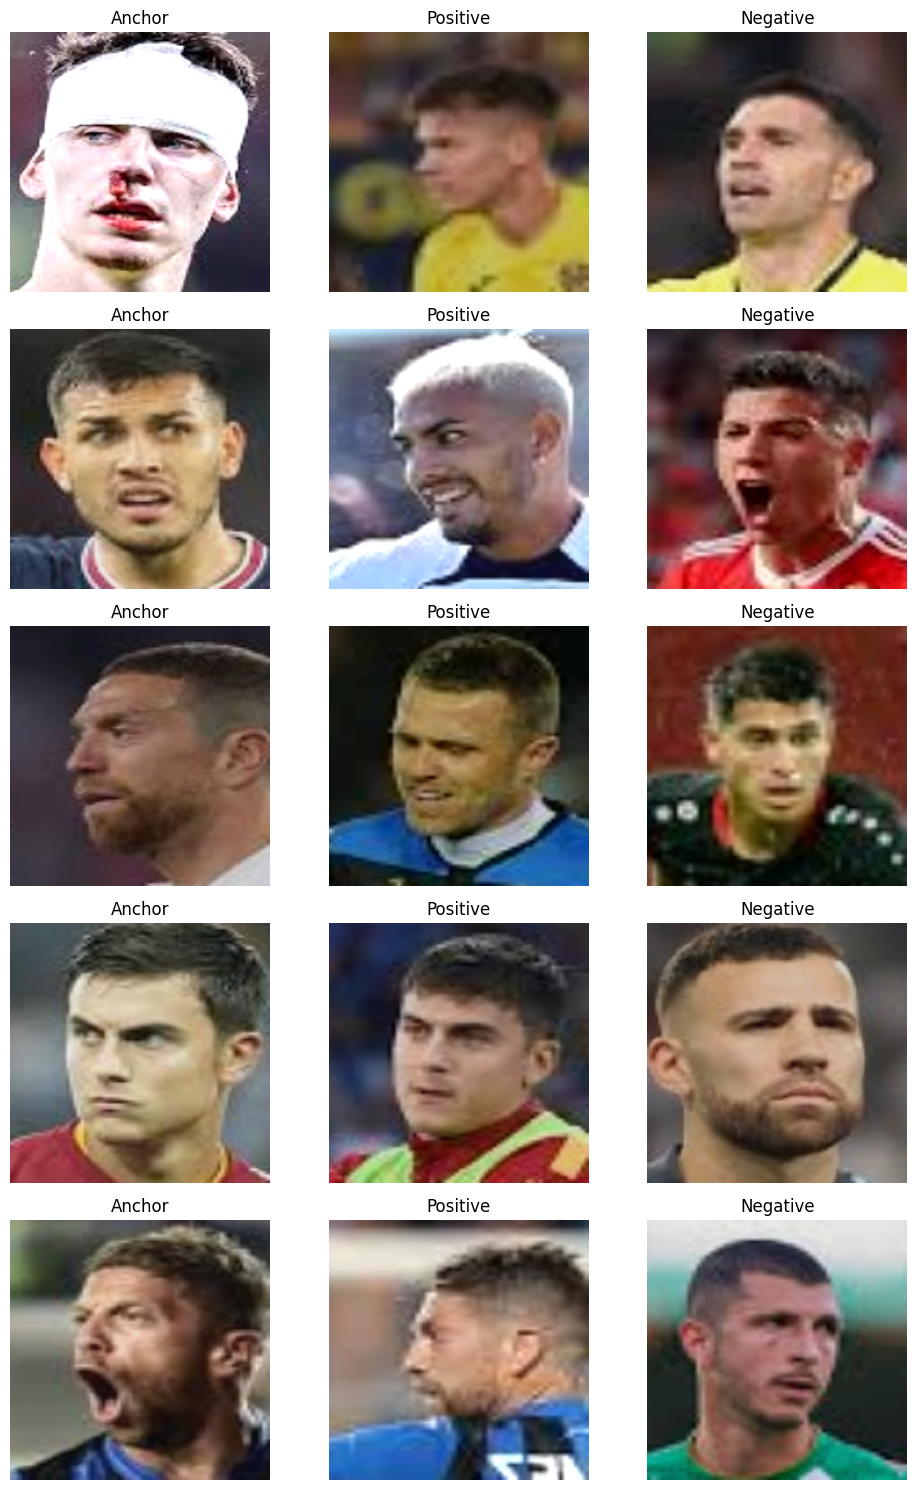

In [ ]:
fig, axes = plt.subplots(
    5,
    3,
    figsize=(10,15)
)

mean = np.array([0.485,0.456,0.406])
std = np.array([0.229,0.224,0.225])

for i in range(5):

    anchor, positive, negative, label = triplet_train_dataset[i]

    samples = [anchor, positive, negative]
    titles = ["Anchor", "Positive", "Negative"]

    for j in range(3):

        img = samples[j].permute(1,2,0).numpy()
        img = std * img + mean
        img = np.clip(img,0,1)

        axes[i,j].imshow(img)
        axes[i,j].set_title(titles[j])
        axes[i,j].axis("off")

plt.tight_layout()
plt.show()